# Huấn Luyện YOLO11 Instance Segmentation (Active Learning / Semi-Supervised)
# Phân bổ Dữ liệu Huấn luyện & Đánh giá:
- **Tập TRAIN mở rộng (9.000 ảnh):** Gồm 7.000 ảnh Train gốc + 2.000 ảnh mới gán nhãn bổ sung (`images/test`).
- **Tập VAL Đánh giá (1.000 ảnh):** Dùng duy nhất 1.000 ảnh tập Validation để tính toán các chỉ số mAP50, mAP50-95 chuẩn xác!
- **Tệp Nhật ký:** Tự động tạo tệp `trainlog.txt` riêng biệt bên cạnh các file mặc định do Ultralytics sinh ra.

## 1. Cài Đặt Thư Viện, Sửa Lỗi OpenCV (`libGL`) & Triton Compiler (`gcc`)

In [ ]:
# CÀI ĐẶT THƯ VIỆN & CẤU HÌNH ĐƯỜNG DẪN DATASET
import os
import sys
import yaml
import torch
from pathlib import Path
from IPython.display import display
import cv2

# Tự động xác định thư mục gốc của Dataset
current_dir = Path.cwd()
if (current_dir / "data.yaml").exists():
    DATASET_ROOT = current_dir
elif (Path("/workspace/yolo11_bdd100k_is_data") / "data.yaml").exists():
    DATASET_ROOT = Path("/workspace/yolo11_bdd100k_is_data")
else:
    DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/workspace"))

RUNS_ROOT = DATASET_ROOT / "runs"
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print(" OpenCV Version:", cv2.__version__)
print(" Thư mục Dataset:", DATASET_ROOT.absolute())
print(" Kiểm tra CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(" Tên GPU:", torch.cuda.get_device_name(0))
    print(f" VRAM khả dụng: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Kiểm tra cấu trúc các thư mục dữ liệu (Bao gồm cả 500 ảnh VN mới gộp)
folders_to_check = [
    "images/train", "images/test", "images/vn_500", "images/val",
    "labels/train", "labels/test", "labels/vn_500", "labels/val"
]
total_train = 0
for folder in folders_to_check:
    p = DATASET_ROOT / folder
    assert p.exists(), f" Thiếu thư mục: {p}"
    count = len(list(p.glob('*')))
    print(f"  {folder:<15}: {count} files")
    if "images" in folder and "val" not in folder:
        total_train += count

print(f"\n TỔNG CỘNG ẢNH HUẤN LUYỆN (TRAIN): {total_train} ảnh (7.000 Train + 2.000 Test + 500 VN)")


 OpenCV Version: 5.0.0
 Thư mục Dataset: /workspace/yolo11_bdd100k_is_data
 Kiểm tra CUDA: True
 Tên GPU: NVIDIA GeForce RTX 5090
 VRAM khả dụng: 33.71 GB
  images/train   : 7000 files
  images/test    : 2000 files
  images/vn_500  : 500 files
  images/val     : 1000 files
  labels/train   : 7000 files
  labels/test    : 1852 files
  labels/vn_500  : 500 files
  labels/val     : 1000 files

🎯 TỔNG CỘNG ẢNH HUẤN LUYỆN (TRAIN): 9500 ảnh (7.000 Train + 2.000 Test + 500 VN)


## 2. Cấu hình File `data_docker.yaml` (Gộp 9.500 ảnh: 7k BDD Train + 2k BDD Test + 500 VN)

In [ ]:
# Đọc file data.yaml gốc và cấu hình gộp 9.500 ảnh vào tập Train
with open(DATASET_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

dataset_config["path"] = str(DATASET_ROOT.absolute().as_posix())
# Gộp cả 3 thư mục: train (7.000), test (2.000) và vn_500 (500 ảnh VN) làm tập Train
dataset_config["train"] = ["images/train", "images/test", "images/vn_500"]
dataset_config["val"] = "images/val"

yaml_docker_path = DATASET_ROOT / "data_docker.yaml"
with open(yaml_docker_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False, allow_unicode=True)

print("=== NỘI DUNG FILE DATA_DOCKER.YAML ===")
with open(yaml_docker_path, "r", encoding="utf-8") as f:
    print(f.read())


=== NỘI DUNG FILE DATA_DOCKER.YAML ===
path: /workspace/yolo11_bdd100k_is_data
train:
- images/train
- images/test
- images/vn_500
val: images/val
names:
  0: bicycle
  1: bus
  2: car
  3: caravan
  4: motorcycle
  5: person
  6: rider
  7: trailer
  8: train
  9: truck



## 3. Huấn Luyện Mô Hình YOLO11 Instance Segmentation (9.500 Ảnh Train)

In [ ]:
from ultralytics import YOLO
import os
import torch

os.environ["TRITON_DISABLE"] = "1"

# Khởi tạo mô hình lớn nhất YOLO11x-seg cho chất lượng phân đoạn cao nhất
MODEL_NAME = "yolo11x-seg.pt"
print(f" Khởi tạo mô hình: {MODEL_NAME}")
model = YOLO(MODEL_NAME)

PROJECT_NAME = str(RUNS_ROOT)
RUN_NAME = "yolo11x_bdd100k_vn_9500_train"

results = model.train(
    data=str(yaml_docker_path),  # File data_docker.yaml (9.500 ảnh Train)
    task="segment",              # Tác vụ Instance Segmentation
    epochs=100,                  # Số Epoch huấn luyện
    imgsz=640,                   # Kích thước ảnh đầu vào (640x640)
    batch=32,                    # Batch size
    optimizer="auto",            # Tự động chọn bộ tối ưu hóa tốt nhất (SGD / AdamW)
    lr0=0.01,                    # Tốc độ học ban đầu (Initial Learning Rate)
    patience=20,                 # Early stopping sau 20 epoch nếu không tăng mAP
    device=0,                    # GPU số 0
    workers=8,                   # Số luồng DataLoader đọc ảnh song song
    amp=True,                   # Tắt AMP để tương thích 100% không yêu cầu Triton
    save=True,                   # Lưu lại Checkpoint
    save_period=10,              # Lưu checkpoint mỗi 10 epoch
    project=PROJECT_NAME,        # Thư mục lưu kết quả
    name=RUN_NAME,               # Tên thư mục đợt train
    pretrained=True              # Kế thừa trọng số Pretrained
)

print(f"\n HOÀN TẤT HUẤN LUYỆN! Trọng số lưu tại: {RUNS_ROOT / RUN_NAME / 'weights' / 'best.pt'}")


🚀 Khởi tạo mô hình: yolo11x-seg.pt
Ultralytics 8.4.126 🚀 Python-3.10.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32150MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/yolo11_bdd100k_is_data/data_docker.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x-seg.pt, momen

[W822 10:31:11.612881293 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 94371840 bytes (free: 6881280, total: 33711521792).
[W822 10:31:11.624172281 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 94371840 bytes (free: 55115776, total: 33711521792).


WARNING ⚠️ CUDA out of memory with batch=32. Reducing to batch=16 and retrying (1/3).
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5590.4±2161.7 MB/s, size: 144.6 KB)


[W822 10:31:12.196222126 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 20971520 bytes (free: 8978432, total: 33711521792).
[W822 10:31:12.196332091 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 20971520 bytes (free: 11075584, total: 33711521792).


train: Scanning /workspace/yolo11_bdd100k_is_data/labels/test.cache... 9352 images, 292 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9500/9500 3.1Git/s 0.0s
train: /workspace/yolo11_bdd100k_is_data/images/test/d3088591-dc0b8312.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d3823fa1-00000000.jpg: 2 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d3cb8fe9-54ba1bbc.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d4187ae6-2587a758.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d449d07e-0867193e.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d4d37c0c-76b3cf39.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d5470ec5-73d442f5.jpg: 1 duplicate labels removed
train: /workspace/yolo11_bdd100k_is_data/images/test/d556ec8c-cd58caaa.jpg: 2 duplicate labels removed
train: /workspace/yolo

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



     36/100      12.3G     0.8716      1.837     0.6053     0.9149          0         56        640: 100% ━━━━━━━━━━━━ 1188/1188 8.4it/s 2:220.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.8it/s 4.2s0.3s
                   all       1000      13008      0.546      0.382      0.379      0.257      0.503      0.341      0.322      0.178

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     37/100      12.3G     0.8631      1.813     0.5997     0.9133          0        129        640: 100% ━━━━━━━━━━━━ 1188/1188 8.3it/s 2:220.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.7it/s 4.3s0.3s
                   all       1000      13008      0.459      0.362      0.366      0.248      0.412      0.302       0.31 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



     57/100      12.3G     0.8034      1.623      0.527     0.8866          0         43        640: 100% ━━━━━━━━━━━━ 1188/1188 8.6it/s 2:180.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.7it/s 4.3s0.3s
                   all       1000      13008      0.621      0.359      0.386      0.264      0.561      0.324      0.333       0.18

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     58/100      12.3G     0.8081       1.63     0.5223     0.8881          0         86        640: 100% ━━━━━━━━━━━━ 1188/1188 8.5it/s 2:200.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.8it/s 4.2s0.3s
                   all       1000      13008      0.593      0.374      0.388      0.261      0.536      0.333      0.329

## 4. Tạo Tệp Nhật Ký Train Log TXT Riêng (`trainlog.txt`)

In [ ]:
# TẠO TỆP TRAINLOG.TXT RIÊNG TỪ KẾT QUẢ ĐỢT TRAIN
import pandas as pd
import datetime

train_log_path = RUNS_ROOT / "trainlog.txt"
csv_path = RUNS_ROOT / RUN_NAME / "results.csv"

with open(train_log_path, "w", encoding="utf-8") as f:
    f.write("=====================================================\n")
    f.write("            NHẬT KÝ HUẤN LUYỆN (TRAINLOG.TXT)\n")
    f.write("=====================================================\n")
    f.write(f"Thời gian xuất: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Mô hình       : {MODEL_NAME}\n")
    f.write(f"Thiết bị GPU  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}\n")
    f.write(f"Đường dẫn lưu : {RUNS_ROOT / RUN_NAME}\n")
    f.write(f"Tổng ảnh Train: 9.500 ảnh (7.000 train gốc + 2.000 test + 500 ảnh VN)\n")
    f.write(f"Tập Validation: 1.000 ảnh chuẩn\n")
    f.write("-----------------------------------------------------\n\n")

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]

        f.write("--- THỐNG KÊ CHI TIẾT TỪNG EPOCH ---\n")
        f.write(f"{'Epoch':<8}{'Box Loss':<12}{'Seg Loss':<12}{'Cls Loss':<12}{'mAP50(M)':<12}{'mAP50-95(M)':<12}\n")
        f.write("-" * 68 + "\n")

        for _, row in df.iterrows():
            ep = int(row.get('epoch', 0))
            box_l = float(row.get('train/box_loss', row.get('val/box_loss', 0)))
            seg_l = float(row.get('train/seg_loss', row.get('val/seg_loss', 0)))
            cls_l = float(row.get('train/cls_loss', row.get('val/cls_loss', 0)))
            map50 = float(row.get('metrics/mAP50(M)', row.get('metrics/mAP50(B)', 0)))
            map50_95 = float(row.get('metrics/mAP50-95(M)', row.get('metrics/mAP50-95(B)', 0)))

            f.write(f"{ep:<8}{box_l:<12.4f}{seg_l:<12.4f}{cls_l:<12.4f}{map50:<12.4f}{map50_95:<12.4f}\n")

        metric = "metrics/mAP50-95(M)" if "metrics/mAP50-95(M)" in df else "metrics/mAP50-95(B)"
        if metric in df:
            best_idx = df[metric].idxmax()
            best_row = df.loc[best_idx]
            f.write("\n-----------------------------------------------------\n")
            f.write(f"🏆 EPOCH TỐT NHẤT: Epoch {int(best_row['epoch'])} | {metric}: {float(best_row[metric]):.4f}\n")

    f.write("=====================================================\n")

print(f" Đã tạo xong file trainlog.txt tại: {train_log_path.absolute()}")


✅ Đã tạo xong file trainlog.txt tại: /workspace/yolo11_bdd100k_is_data/runs/trainlog.txt


## 5. Biểu Đồ Lịch Sử Huấn Luyện (Loss & mAP)

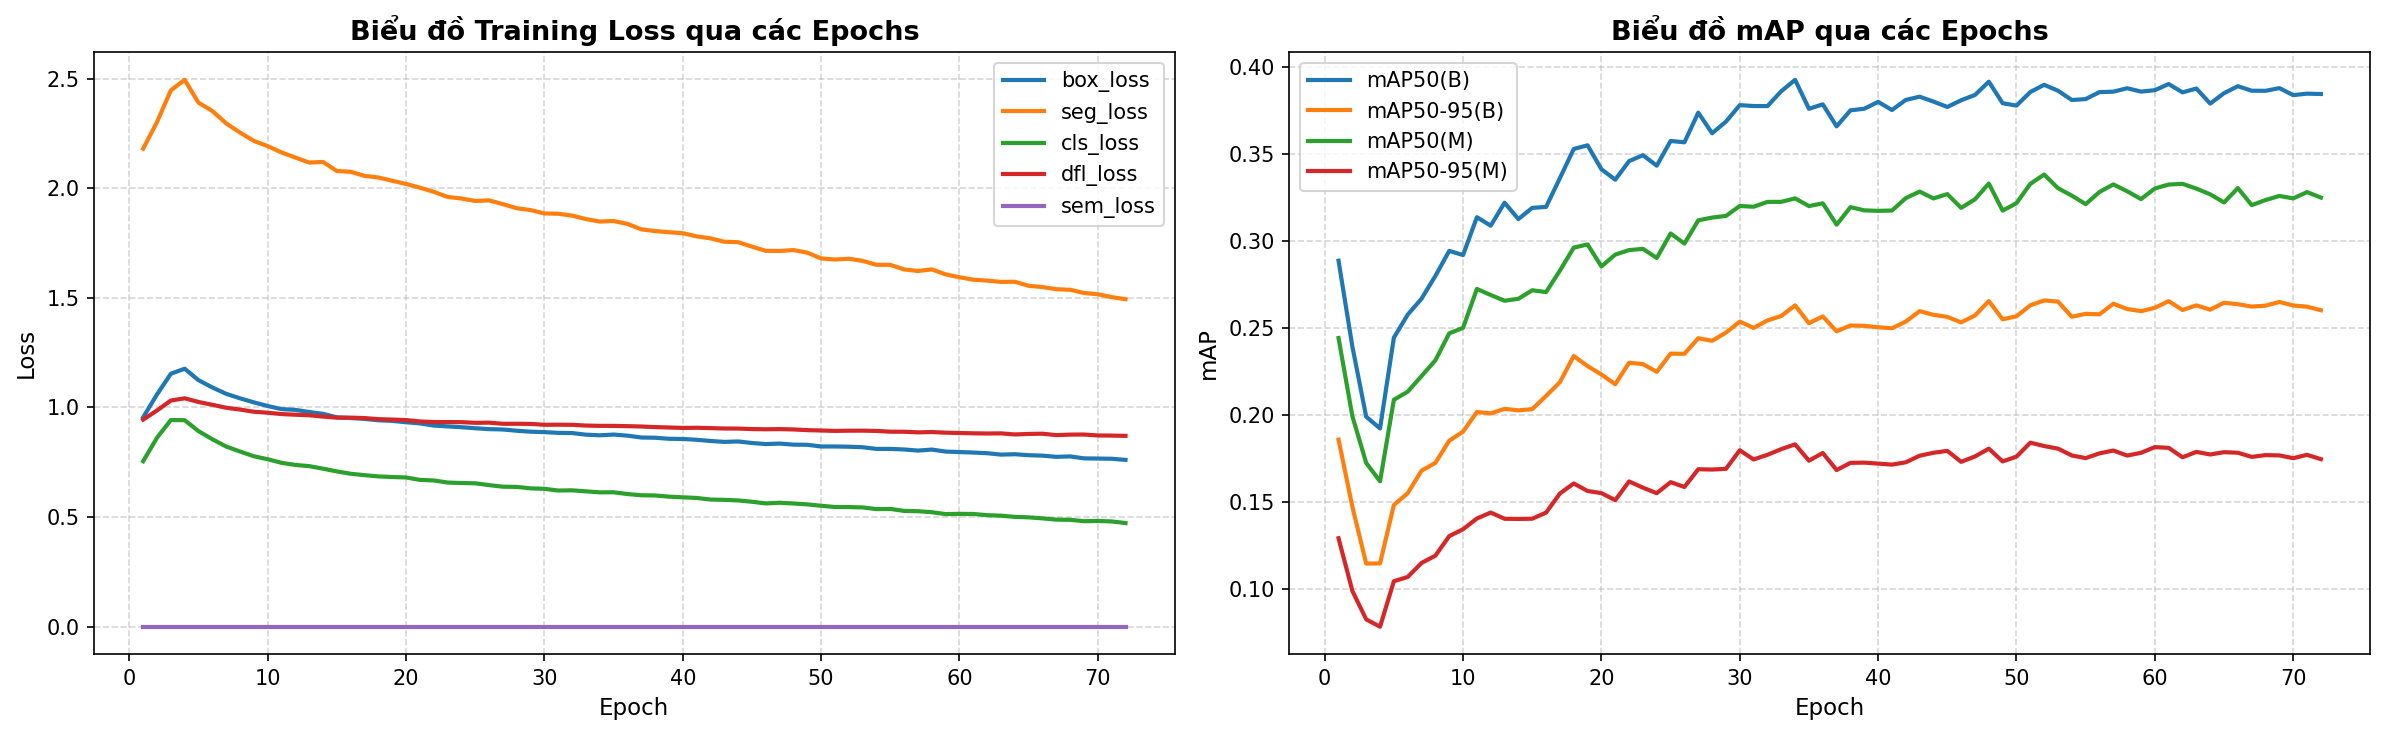

🎉 ĐÃ LƯU BIỂU ĐỒ 1 THÀNH FILE ẢNH TẠI:
👉 /workspace/yolo11_bdd100k_is_data/runs/yolo11x_bdd100k_vn_9500_train/training_loss_and_map_curves.png


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

if csv_path.exists():
    history = pd.read_csv(csv_path)
    history.columns = [c.strip() for c in history.columns]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=150)

    # 1. Biểu đồ Training Loss
    loss_cols = [c for c in history.columns if "loss" in c.lower() and "val" not in c.lower()]
    for col in loss_cols:
        axes[0].plot(history["epoch"], history[col], label=col.replace("train/", ""), linewidth=2)
    axes[0].set_title("Biểu đồ Training Loss qua các Epochs", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # 2. Biểu đồ mAP
    map_cols = [c for c in history.columns if "mAP" in c]
    for col in map_cols:
        axes[1].plot(history["epoch"], history[col], label=col.replace("metrics/", ""), linewidth=2)
    axes[1].set_title("Biểu đồ mAP qua các Epochs", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("mAP", fontsize=11)
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    save_path_1 = RUNS_ROOT / RUN_NAME / "training_loss_and_map_curves.png"
    plt.savefig(save_path_1, dpi=300, bbox_inches='tight')
    plt.show()

    print(f" ĐÃ LƯU BIỂU ĐỒ 1 THÀNH FILE ẢNH TẠI:\n👉 {save_path_1.absolute()}")
else:
    print(" Chưa tìm thấy file results.csv!")


/tmp/ipykernel_2256/2334995124.py:53: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2256/2334995124.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
/opt/jupyter_venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


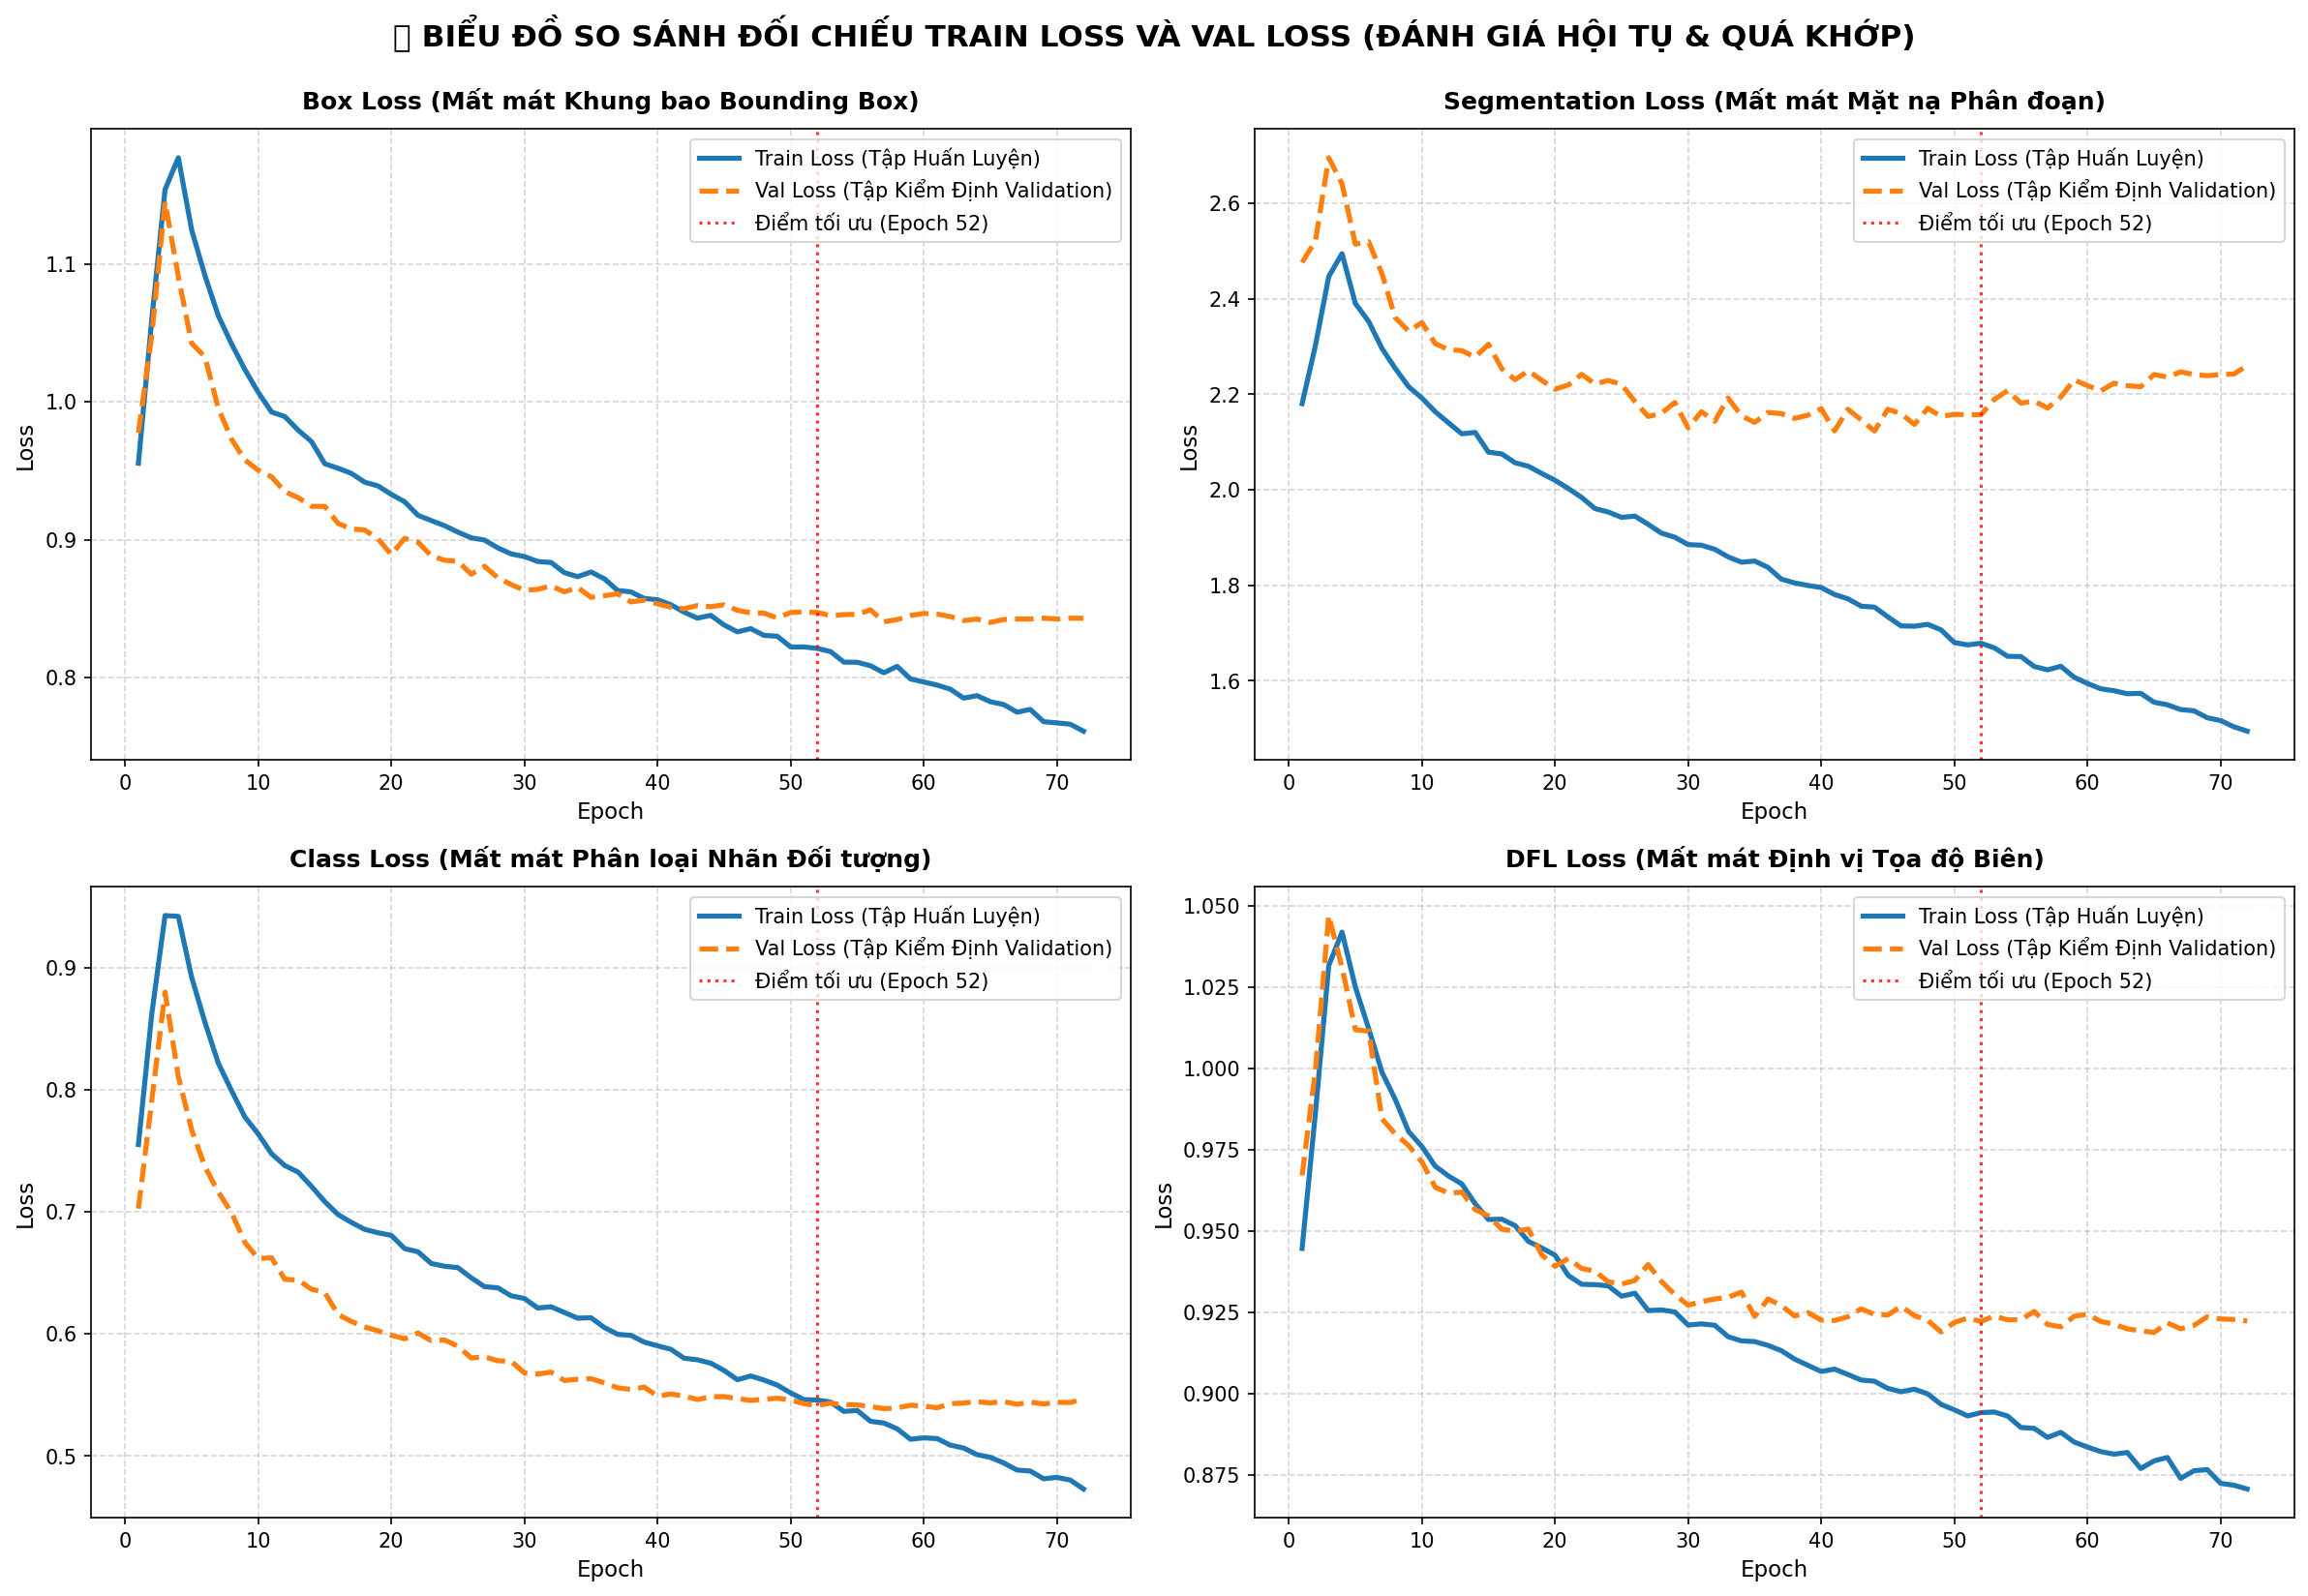

🎉 ĐÃ LƯU ẢNH BIỂU ĐỒ CHUẨN IN ẤN (300 DPI) TẠI:
👉 /workspace/yolo11_bdd100k_is_data/runs/yolo11x_bdd100k_vn_9500_train/train_val_loss_comparison.png


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

if csv_path.exists():
    history = pd.read_csv(csv_path)
    history.columns = [c.strip() for c in history.columns]


    fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=150)

    loss_configs = [
        ("box_loss", "Box Loss (Mất mát Khung bao Bounding Box)", axes[0, 0]),
        ("seg_loss", "Segmentation Loss (Mất mát Mặt nạ Phân đoạn)", axes[0, 1]),
        ("cls_loss", "Class Loss (Mất mát Phân loại Nhãn Đối tượng)", axes[1, 0]),
        ("dfl_loss", "DFL Loss (Mất mát Định vị Tọa độ Biên)", axes[1, 1])
    ]

    # Tìm Epoch có mAP50(M) cao nhất để đánh dấu điểm tối ưu (Best Model)
    best_epoch = None
    if "metrics/mAP50(M)" in history.columns:
        best_epoch = int(history.loc[history["metrics/mAP50(M)"].idxmax(), "epoch"])

    for ltype, title, ax in loss_configs:
        train_col = f"train/{ltype}"
        val_col = f"val/{ltype}"

        if train_col in history.columns and val_col in history.columns:
            # Đường Train Loss (Xanh dương nét liền)
            ax.plot(history["epoch"], history[train_col],
                    label="Train Loss (Tập Huấn Luyện)",
                    color="#1f77b4", linewidth=2.5)

            # Đường Val Loss (Cam nét đứt)
            ax.plot(history["epoch"], history[val_col],
                    label="Val Loss (Tập Kiểm Định Validation)",
                    color="#ff7f0e", linewidth=2.5, linestyle="--")

            # Vạch đỏ đánh dấu Best Epoch
            if best_epoch is not None:
                ax.axvline(x=best_epoch, color="red", linestyle=":", alpha=0.8,
                           label=f"Điểm tối ưu (Epoch {best_epoch})")

            ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
            ax.set_xlabel("Epoch", fontsize=11)
            ax.set_ylabel("Loss", fontsize=11)
            ax.legend(fontsize=10, loc="upper right")
            ax.grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(" BIỂU ĐỒ SO SÁNH ĐỐI CHIẾU TRAIN LOSS VÀ VAL LOSS (ĐÁNH GIÁ HỘI TỤ & QUÁ KHỚP)",
                 fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout()

    # Tự động xuất ảnh độ phân giải cao 300 DPI để chèn vào Báo cáo Khóa Luận
    save_chart_path = RUNS_ROOT / RUN_NAME / "train_val_loss_comparison.png"
    plt.savefig(save_chart_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" ĐÃ LƯU ẢNH BIỂU ĐỒ CHUẨN IN ẤN (300 DPI) TẠI:\n {save_chart_path.absolute()}")
else:
    print(" Chưa tìm thấy file results.csv!")


## 6. Đánh Giá Mô Hình Độc Lập trên Tập Validation (1.000 Ảnh)

In [ ]:
best_weight = RUNS_ROOT / RUN_NAME / "weights" / "best.pt"
if best_weight.exists():
    best_model = YOLO(str(best_weight))
else:
    best_model = model

print("=== ĐÁNH GIÁ CHỈ SỐ MAP TRÊN TẬP VAL (1.000 ÁNH CHUẨN) ===")
val_metrics = best_model.val(data=str(yaml_docker_path), split="val", imgsz=640, device=0)
print(f"Val Mask mAP50-95: {val_metrics.seg.map:.4f} | mAP50: {val_metrics.seg.map50:.4f}")

=== ĐÁNH GIÁ CHỈ SỐ MAP TRÊN TẬP VAL (1.000 ÁNH CHUẨN) ===
Ultralytics 8.4.126 🚀 Python-3.10.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32150MiB)
YOLO11x-seg summary (fused): 204 layers, 62,013,678 parameters, 0 gradients, 296.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5216.9±3178.9 MB/s, size: 178.7 KB)
val: Scanning /workspace/yolo11_bdd100k_is_data/labels/val.cache... 1000 images, 19 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 349.5Mit/s 0.0s
val: /workspace/yolo11_bdd100k_is_data/images/val/8114e021-00000000.jpg: 1 duplicate labels removed
val: /workspace/yolo11_bdd100k_is_data/images/val/898ac5b9-00000000.jpg: 1 duplicate labels removed
val: /workspace/yolo11_bdd100k_is_data/images/val/a4455970-00000000.jpg: 1 duplicate labels removed
val: /workspace/yolo11_bdd100k_is_data/images/val/ab309345-00000000.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R    